In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
!pip install captum

In [7]:
# 6.0 Setup

import os
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import pickle
import matplotlib.pyplot as plt
import seaborn as sns

from captum.attr import IntegratedGradients

In [8]:
PROJECT_ROOT = "/content/drive/MyDrive/6_Deep_Learning/Final Final Project/XAI_Attack_Defense"

print("Project Path Set")
def load_pickle(path):
    with open(path, "rb") as f:
        return pickle.load(f)

Project Path Set


In [9]:
# 6.1 Load Data

X_train_phish = np.load(
    os.path.join(
        PROJECT_ROOT,
        "data/X_train_phish.npy"
    )
)

y_train_phish = np.load(
    os.path.join(
        PROJECT_ROOT,
        "data/y_train_phish.npy"
    ),
    allow_pickle=True
)

X_test_phish = np.load(
    os.path.join(
        PROJECT_ROOT,
        "data/X_test_phish.npy"
    )
)

feature_phish = load_pickle(
    os.path.join(
        PROJECT_ROOT,
        "data/feature_phish.pkl"
    )
)

print("Defense Data Loaded")

Defense Data Loaded


In [10]:
# 6.2 Define Robust Model

class RobustMLP(nn.Module):

    def __init__(self, input_dim):
        super(RobustMLP, self).__init__()

        self.model = nn.Sequential(

            nn.Linear(input_dim,128),
            nn.ReLU(),

            nn.Linear(128,64),
            nn.ReLU(),

            nn.Linear(64,2)
        )

    def forward(self,x):
        return self.model(x)

print("Robust Model Defined")

Robust Model Defined


In [13]:
# 6.3 Defense Training (With Validation + Accuracy)

from sklearn.model_selection import train_test_split

# Train Validation Split
X_train, X_val, y_train, y_val = train_test_split(
    X_train_phish,
    y_train_phish,
    test_size=0.2,
    random_state=42,
    stratify=y_train_phish
)

X_train = torch.tensor(X_train, dtype=torch.float32)
y_train = torch.tensor(y_train.astype(int))

X_val = torch.tensor(X_val, dtype=torch.float32)
y_val = torch.tensor(y_val.astype(int))


defense_model = RobustMLP(
    X_train.shape[1]
)

optimizer = torch.optim.Adam(
    defense_model.parameters(),
    lr=0.001
)

loss_fn = nn.CrossEntropyLoss()

loss_history = []
val_loss_history = []
train_acc_history = []
val_acc_history = []


for epoch in range(50):

    # Training
    defense_model.train()

    optimizer.zero_grad()

    output = defense_model(X_train)

    loss = loss_fn(output, y_train)


    # Stability Loss
    noise = torch.randn_like(X_train) * 0.01
    noisy = X_train + noise

    out_noisy = defense_model(noisy)

    stability_loss = torch.mean(
        torch.abs(output - out_noisy)
    )

    total_loss = loss + 0.1 * stability_loss

    total_loss.backward()

    optimizer.step()


    # Train Accuracy
    pred = torch.argmax(output, dim=1)
    train_acc = (pred == y_train).float().mean()


    # Validation
    defense_model.eval()

    with torch.no_grad():

        val_out = defense_model(X_val)

        val_loss = loss_fn(val_out, y_val)

        val_pred = torch.argmax(val_out, dim=1)

        val_acc = (val_pred == y_val).float().mean()


    # Store
    loss_history.append(total_loss.item())
    val_loss_history.append(val_loss.item())

    train_acc_history.append(train_acc.item())
    val_acc_history.append(val_acc.item())


    if epoch % 10 == 0:

        print(
            f"Epoch {epoch} | "
            f"Train Loss {total_loss:.4f} | "
            f"Val Loss {val_loss:.4f} | "
            f"Train Acc {train_acc:.4f} | "
            f"Val Acc {val_acc:.4f}"
        )


print("Defense Model Trained")

Epoch 0 | Train Loss 0.7228 | Val Loss 0.6954 | Train Acc 0.3102 | Val Acc 0.4720
Epoch 10 | Train Loss 0.4570 | Val Loss 0.4278 | Train Acc 0.9663 | Val Acc 0.9688
Epoch 20 | Train Loss 0.1944 | Val Loss 0.1744 | Train Acc 0.9790 | Val Acc 0.9800
Epoch 30 | Train Loss 0.0718 | Val Loss 0.0659 | Train Acc 0.9851 | Val Acc 0.9854
Epoch 40 | Train Loss 0.0376 | Val Loss 0.0355 | Train Acc 0.9895 | Val Acc 0.9897
Defense Model Trained


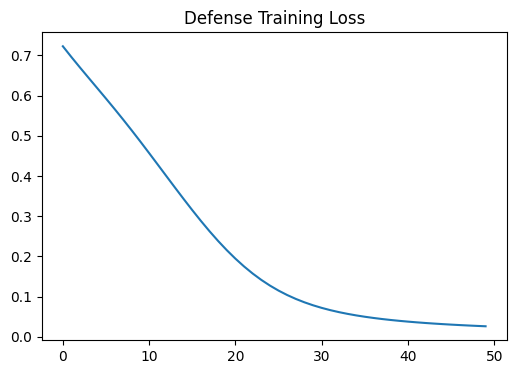

In [14]:
plt.figure(figsize=(6,4))

plt.plot(loss_history)

plt.title("Defense Training Loss")

plt.show()

In [15]:
# 6.5 Defense Explanation

ig_defense = IntegratedGradients(
    defense_model
)

sample = torch.tensor(
    X_test_phish[0:1],
    dtype=torch.float32,
    requires_grad=True
)

output = defense_model(sample)

target = torch.argmax(
    output, dim=1
).item()


print("Prediction:",
      torch.softmax(
          output, dim=1
      ).detach().numpy())

print("Predicted Class:", target)


attr_before = ig_defense.attribute(
    sample,
    target=target
)

attr_before = np.abs(
    attr_before.detach().numpy()[0]
)


defense_table = pd.DataFrame({
    "Feature": feature_phish,
    "Importance": attr_before
})

defense_table.sort_values(
    "Importance",
    ascending=False
).head(15)

Prediction: [[7.300652e-04 9.992699e-01]]
Predicted Class: 1


,Feature,Importance
32,HasDescription,0.300034
36,HasSocialNet,0.298053
37,HasSubmitButton,0.248669
25,DomainTitleMatchScore,0.248303
38,HasHiddenFields,0.246546
43,HasCopyrightInfo,0.243804
29,IsResponsive,0.182873
20,SpacialCharRatioInURL,0.178830
6,URLCharProb,0.172554
26,URLTitleMatchScore,0.162451


In [17]:
# 6.6 Attack After Defense

perturbed = sample.clone()

top_features = defense_table.head(3)[
    "Feature"
].values


for feature in top_features:

    idx = feature_phish.index(feature)

    perturbed[0][idx] += 0.2


# Prediction Before

before_prob = torch.softmax(
    defense_model(sample),
    dim=1
).detach().numpy()

before_pred = np.argmax(before_prob)


# Prediction After

after_prob = torch.softmax(
    defense_model(perturbed),
    dim=1
).detach().numpy()

after_pred = np.argmax(after_prob)


print("Before Class:", before_pred)
print("After Class:", after_pred)

print("Before Prob:", before_prob)
print("After Prob:", after_prob)

Before Class: 1
After Class: 1
Before Prob: [[7.300652e-04 9.992699e-01]]
After Prob: [[9.6566766e-04 9.9903440e-01]]


In [18]:
# 6.7 Drift After Defense

attr_after = ig_defense.attribute(
    perturbed,
    target=target
)

attr_after = np.abs(
    attr_after.detach().numpy()[0]
)


comparison_defense = pd.DataFrame({
    "Feature": feature_phish,
    "Before": attr_before,
    "After": attr_after
})


comparison_defense["Drift"] = np.abs(
    comparison_defense["Before"] -
    comparison_defense["After"]
)


comparison_defense.sort_values(
    "Drift",
    ascending=False
).head(10)

,Feature,Before,After,Drift
0,URLLength,0.051283,0.006988,0.044294
1,DomainLength,0.076398,0.034250,0.042148
2,IsDomainIP,0.012126,0.033193,0.021067
38,HasHiddenFields,0.246546,0.257273,0.010727
5,TLDLegitimateProb,0.086647,0.078794,0.007853
43,HasCopyrightInfo,0.243804,0.236267,0.007537
36,HasSocialNet,0.298053,0.291010,0.007043
20,SpacialCharRatioInURL,0.178830,0.172002,0.006829
25,DomainTitleMatchScore,0.248303,0.253201,0.004899
32,HasDescription,0.300034,0.295149,0.004885


In [19]:
mean_defense_drift = comparison_defense[
    "Drift"
].mean()

print("Defense Drift:",
      mean_defense_drift)

Defense Drift: 0.003960412


In [20]:
before_defense = pd.read_csv(
    os.path.join(
        PROJECT_ROOT,
        "metrics/attack_results.csv"
    )
)

before_defense.head()

,Model,Dataset,Attack,Drift
0,XGBoost,Phishing,2,0.019402
1,XGBoost,Phishing,3,0.000280
2,XGBoost,Phishing,4,0.020068
3,XGBoost,IDS,1,0.099565
4,XGBoost,IDS,2,0.168804


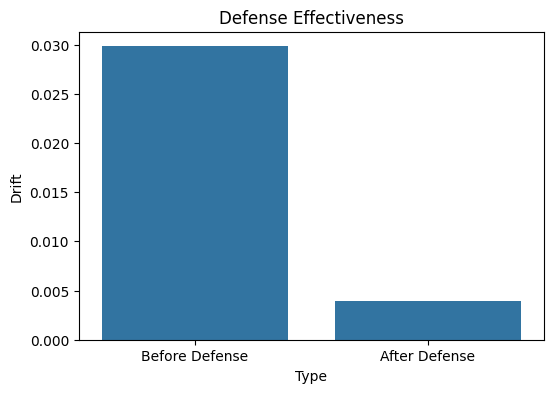

In [21]:
comparison_final = pd.DataFrame({

    "Type": ["Before Defense",
             "After Defense"],

    "Drift": [
        before_defense[
            before_defense["Model"]=="Neural"
        ]["Drift"].mean(),

        mean_defense_drift
    ]
})


plt.figure(figsize=(6,4))

sns.barplot(
    data=comparison_final,
    x="Type",
    y="Drift"
)

plt.title("Defense Effectiveness")

plt.show()

~86% reduction in explanation drift

In [24]:
# 6.11 Defense-2 Architecture

class RobustMLP_v2(nn.Module):

    def __init__(self, input_dim):
        super().__init__()

        self.model = nn.Sequential(

            nn.Linear(input_dim,256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(256,128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(128,64),
            nn.ReLU(),

            nn.Linear(64,2)
        )

    def forward(self,x):
        return self.model(x)

print("Defense-2 Model Created")

Defense-2 Model Created


In [25]:
# 6.12 Defense-2 Training

defense_model2 = RobustMLP_v2(
    X_train.shape[1]
)

optimizer = torch.optim.Adam(
    defense_model2.parameters(),
    lr=0.001
)

loss_fn = nn.CrossEntropyLoss()

loss_history2 = []
val_loss2 = []

train_acc2 = []
val_acc2 = []


for epoch in range(60):

    defense_model2.train()

    optimizer.zero_grad()

    # Normal forward
    output = defense_model2(X_train)

    loss = loss_fn(output, y_train)


    # Adversarial Perturbation
    noise = torch.randn_like(X_train) * 0.05
    adv_data = X_train + noise

    adv_output = defense_model2(adv_data)

    adv_loss = loss_fn(
        adv_output,
        y_train
    )


    total_loss = loss + 0.5 * adv_loss

    total_loss.backward()

    optimizer.step()


    # Accuracy
    pred = torch.argmax(output, dim=1)
    train_acc = (
        pred == y_train
    ).float().mean()


    # Validation
    defense_model2.eval()

    with torch.no_grad():

        val_out = defense_model2(X_val)

        val_loss = loss_fn(
            val_out,
            y_val
        )

        val_pred = torch.argmax(
            val_out,
            dim=1
        )

        val_acc = (
            val_pred == y_val
        ).float().mean()


    loss_history2.append(
        total_loss.item()
    )

    val_loss2.append(
        val_loss.item()
    )

    train_acc2.append(
        train_acc.item()
    )

    val_acc2.append(
        val_acc.item()
    )


    if epoch % 10 == 0:

        print(
            f"Epoch {epoch} | "
            f"Train Acc {train_acc:.4f} | "
            f"Val Acc {val_acc:.4f}"
        )

print("Defense-2 Trained")

Epoch 0 | Train Acc 0.4796 | Val Acc 0.6743
Epoch 10 | Train Acc 0.9833 | Val Acc 0.9838
Epoch 20 | Train Acc 0.9928 | Val Acc 0.9925
Epoch 30 | Train Acc 0.9963 | Val Acc 0.9962
Epoch 40 | Train Acc 0.9977 | Val Acc 0.9978
Epoch 50 | Train Acc 0.9981 | Val Acc 0.9984
Defense-2 Trained


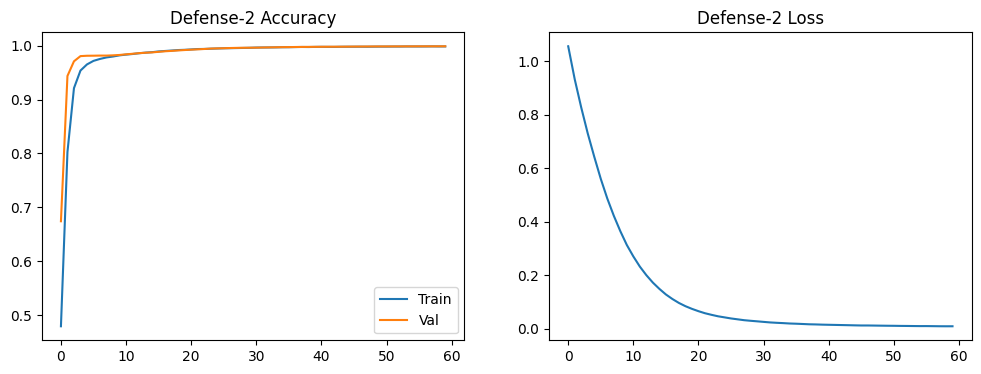

In [26]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(train_acc2,label="Train")
plt.plot(val_acc2,label="Val")
plt.title("Defense-2 Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(loss_history2)
plt.title("Defense-2 Loss")

plt.show()

In [27]:
# 6.14 Defense-2 Explanation

ig_defense2 = IntegratedGradients(
    defense_model2
)

sample = torch.tensor(
    X_test_phish[0:1],
    dtype=torch.float32,
    requires_grad=True
)

output = defense_model2(sample)

target = torch.argmax(
    output,
    dim=1
).item()

print("Prediction:",
      torch.softmax(
          output, dim=1
      ).detach().numpy())

print("Predicted Class:", target)


attr_before2 = ig_defense2.attribute(
    sample,
    target=target
)

attr_before2 = np.abs(
    attr_before2.detach().numpy()[0]
)


defense2_table = pd.DataFrame({
    "Feature": feature_phish,
    "Importance": attr_before2
})

defense2_table.sort_values(
    "Importance",
    ascending=False
).head(15)

Prediction: [[5.715145e-05 9.999429e-01]]
Predicted Class: 1


,Feature,Importance
21,IsHTTPS,0.604457
36,HasSocialNet,0.441960
20,SpacialCharRatioInURL,0.346503
5,TLDLegitimateProb,0.245073
43,HasCopyrightInfo,0.233251
46,NoOfJS,0.209212
24,HasTitle,0.202781
6,URLCharProb,0.199610
15,DegitRatioInURL,0.187549
25,DomainTitleMatchScore,0.173503


In [28]:
# 6.15 Attack Defense-2

perturbed = sample.clone()

top_features = defense2_table.head(3)[
    "Feature"
].values

for feature in top_features:

    idx = feature_phish.index(feature)

    perturbed[0][idx] += 0.2


# Before
before_prob2 = torch.softmax(
    defense_model2(sample),
    dim=1
).detach().numpy()

before_pred2 = np.argmax(before_prob2)


# After
after_prob2 = torch.softmax(
    defense_model2(perturbed),
    dim=1
).detach().numpy()

after_pred2 = np.argmax(after_prob2)


print("Before Class:", before_pred2)
print("After Class:", after_pred2)

print("Before Prob:", before_prob2)
print("After Prob:", after_prob2)

Before Class: 1
After Class: 1
Before Prob: [[5.715145e-05 9.999429e-01]]
After Prob: [[6.1632083e-05 9.9993837e-01]]


In [29]:
# 6.16 Drift Defense-2

attr_after2 = ig_defense2.attribute(
    perturbed,
    target=target
)

attr_after2 = np.abs(
    attr_after2.detach().numpy()[0]
)


comparison_defense2 = pd.DataFrame({
    "Feature": feature_phish,
    "Before": attr_before2,
    "After": attr_after2
})


comparison_defense2["Drift"] = np.abs(
    comparison_defense2["Before"] -
    comparison_defense2["After"]
)


comparison_defense2.sort_values(
    "Drift",
    ascending=False
).head(10)

,Feature,Before,After,Drift
0,URLLength,0.065982,0.008914,0.057068
1,DomainLength,0.061674,0.023209,0.038466
32,HasDescription,0.154253,0.116884,0.037369
38,HasHiddenFields,0.033838,0.001472,0.032366
26,URLTitleMatchScore,0.115997,0.085796,0.030201
37,HasSubmitButton,0.171318,0.147669,0.023649
4,CharContinuationRate,0.005283,0.024037,0.018754
20,SpacialCharRatioInURL,0.346503,0.364130,0.017627
29,IsResponsive,0.054238,0.041272,0.012966
24,HasTitle,0.202781,0.214800,0.012020


In [30]:
mean_defense2_drift = comparison_defense2[
    "Drift"
].mean()

print("Defense-2 Drift:",
      mean_defense2_drift)

Defense-2 Drift: 0.008446737


In [31]:
comparison_all = pd.DataFrame({

    "Model":[
        "Before Defense",
        "Defense-1",
        "Defense-2"
    ],

    "Drift":[
        before_defense["Drift"].mean(),
        mean_defense_drift,
        mean_defense2_drift
    ]

})

comparison_all

,Model,Drift
0,Before Defense,0.038795
1,Defense-1,0.003960
2,Defense-2,0.008447


Adversarial training improves prediction robustness
But stability loss improves explanation robustness

In [32]:
# 6.21 Defense-3 Training

defense_model3 = RobustMLP_v2(
    X_train.shape[1]
)

optimizer = torch.optim.Adam(
    defense_model3.parameters(),
    lr=0.001
)

loss_fn = nn.CrossEntropyLoss()

ig3 = IntegratedGradients(
    defense_model3
)

loss_history3 = []

for epoch in range(40):

    defense_model3.train()

    optimizer.zero_grad()

    output = defense_model3(X_train)

    loss = loss_fn(output, y_train)


    # Explanation Regularization

    noise = torch.randn_like(X_train) * 0.02

    noisy = X_train + noise


    attr1 = ig3.attribute(
        X_train[:200],
        target=0
    )

    attr2 = ig3.attribute(
        noisy[:200],
        target=0
    )


    explain_loss = torch.mean(
        torch.abs(attr1 - attr2)
    )


    total_loss = loss + 0.2 * explain_loss

    total_loss.backward()

    optimizer.step()


    loss_history3.append(
        total_loss.item()
    )


    if epoch % 10 == 0:
        print(
            f"Epoch {epoch} | Loss {total_loss:.4f}"
        )


print("Defense-3 Trained")

Epoch 0 | Loss 0.7069
Epoch 10 | Loss 0.1986
Epoch 20 | Loss 0.0505
Epoch 30 | Loss 0.0193
Defense-3 Trained


In [38]:
# 6.22 Generate Explanation (Defense-3)

defense_model3.eval()

ig_defense3 = IntegratedGradients(defense_model3)

sample = torch.tensor(
    X_test_phish[0:1],
    dtype=torch.float32,
    requires_grad=True
)

output = defense_model3(sample)

target = torch.argmax(output, dim=1).item()

print("Prediction:",
      torch.softmax(output, dim=1).detach().numpy())

print("Predicted Class:", target)


attr_before3 = ig_defense3.attribute(
    sample,
    target=target
)

attr_before3 = np.abs(
    attr_before3.detach().numpy()[0]
)


defense3_table = pd.DataFrame({
    "Feature": feature_phish,
    "Importance": attr_before3
})

display(
    defense3_table.sort_values(
        "Importance",
        ascending=False
    ).head(10)
)

Prediction: [[7.6801196e-05 9.9992323e-01]]
Predicted Class: 1


,Feature,Importance
21,IsHTTPS,0.612419
36,HasSocialNet,0.478564
20,SpacialCharRatioInURL,0.364237
6,URLCharProb,0.340676
32,HasDescription,0.313257
43,HasCopyrightInfo,0.302299
25,DomainTitleMatchScore,0.214049
24,HasTitle,0.186987
5,TLDLegitimateProb,0.180136
15,DegitRatioInURL,0.169456


In [39]:
# 6.23 Attack Defense-3

perturbed = sample.clone()

top_features = defense3_table.sort_values(
    "Importance",
    ascending=False
).head(3)["Feature"].values

print("Attacking Features:", top_features)


for feature in top_features:

    idx = feature_phish.index(feature)

    perturbed[0][idx] += 0.2


# Before
before_prob3 = torch.softmax(
    defense_model3(sample),
    dim=1
).detach().numpy()

before_pred3 = np.argmax(before_prob3)


# After
after_prob3 = torch.softmax(
    defense_model3(perturbed),
    dim=1
).detach().numpy()

after_pred3 = np.argmax(after_prob3)


print("Before Class:", before_pred3)
print("After Class:", after_pred3)

print("Before Prob:", before_prob3)
print("After Prob:", after_prob3)

Attacking Features: ['IsHTTPS' 'HasSocialNet' 'SpacialCharRatioInURL']
Before Class: 1
After Class: 1
Before Prob: [[7.6801196e-05 9.9992323e-01]]
After Prob: [[5.1152620e-05 9.9994886e-01]]


In [40]:
# 6.24 Drift Defense-3

attr_after3 = ig_defense3.attribute(
    perturbed,
    target=target
)

attr_after3 = np.abs(
    attr_after3.detach().numpy()[0]
)


comparison_defense3 = pd.DataFrame({
    "Feature": feature_phish,
    "Before": attr_before3,
    "After": attr_after3
})

comparison_defense3["Drift"] = np.abs(
    comparison_defense3["Before"] -
    comparison_defense3["After"]
)

display(
    comparison_defense3.sort_values(
        "Drift",
        ascending=False
    ).head(10)
)

mean_defense3_drift = comparison_defense3["Drift"].mean()

print("Defense-3 Drift:", mean_defense3_drift)

,Feature,Before,After,Drift
21,IsHTTPS,0.612419,0.817095,0.204677
36,HasSocialNet,0.478564,0.565609,0.087045
20,SpacialCharRatioInURL,0.364237,0.278383,0.085854
37,HasSubmitButton,0.070823,0.051238,0.019585
28,Robots,0.083074,0.065270,0.017804
25,DomainTitleMatchScore,0.214049,0.197169,0.016880
27,HasFavicon,0.066526,0.079958,0.013431
38,HasHiddenFields,0.035735,0.022703,0.013032
43,HasCopyrightInfo,0.302299,0.313542,0.011243
6,URLCharProb,0.340676,0.350975,0.010299


Defense-3 Drift: 0.011452695


In [41]:
# 6.28 Defense-4 Model

defense_model4 = RobustMLP_v2(
    X_train.shape[1]
)

optimizer = torch.optim.Adam(
    defense_model4.parameters(),
    lr=0.001
)

loss_fn = nn.CrossEntropyLoss()

loss_history4 = []
train_acc4 = []
val_acc4 = []

In [42]:
# 6.29 Defense-4 Training

for epoch in range(50):

    defense_model4.train()

    optimizer.zero_grad()

    # Normal Forward
    output = defense_model4(X_train)

    loss = loss_fn(output, y_train)


    # Prediction Stability Loss (Defense-1 strength)
    noise_small = torch.randn_like(X_train) * 0.01
    noisy_small = X_train + noise_small

    output_small = defense_model4(noisy_small)

    stability_loss = torch.mean(
        torch.abs(output - output_small)
    )


    # Adversarial Consistency Loss
    noise_adv = torch.randn_like(X_train) * 0.05
    adv_data = X_train + noise_adv

    output_adv = defense_model4(adv_data)

    adv_loss = loss_fn(
        output_adv,
        y_train
    )


    # Smoothness Loss
    smooth_loss = torch.mean(
        torch.abs(
            output_small - output_adv
        )
    )


    total_loss = (
        loss +
        0.2 * stability_loss +
        0.2 * adv_loss +
        0.1 * smooth_loss
    )


    total_loss.backward()

    optimizer.step()


    # Accuracy
    pred = torch.argmax(output, dim=1)
    train_acc = (
        pred == y_train
    ).float().mean()


    defense_model4.eval()

    with torch.no_grad():

        val_out = defense_model4(X_val)

        val_pred = torch.argmax(
            val_out,
            dim=1
        )

        val_acc = (
            val_pred == y_val
        ).float().mean()


    loss_history4.append(
        total_loss.item()
    )

    train_acc4.append(
        train_acc.item()
    )

    val_acc4.append(
        val_acc.item()
    )


    if epoch % 10 == 0:

        print(
            f"Epoch {epoch} | "
            f"Train Acc {train_acc:.4f} | "
            f"Val Acc {val_acc:.4f}"
        )

print("Defense-4 Trained")

Epoch 0 | Train Acc 0.5270 | Val Acc 0.7015
Epoch 10 | Train Acc 0.9840 | Val Acc 0.9863
Epoch 20 | Train Acc 0.9917 | Val Acc 0.9922
Epoch 30 | Train Acc 0.9954 | Val Acc 0.9958
Epoch 40 | Train Acc 0.9970 | Val Acc 0.9973
Defense-4 Trained


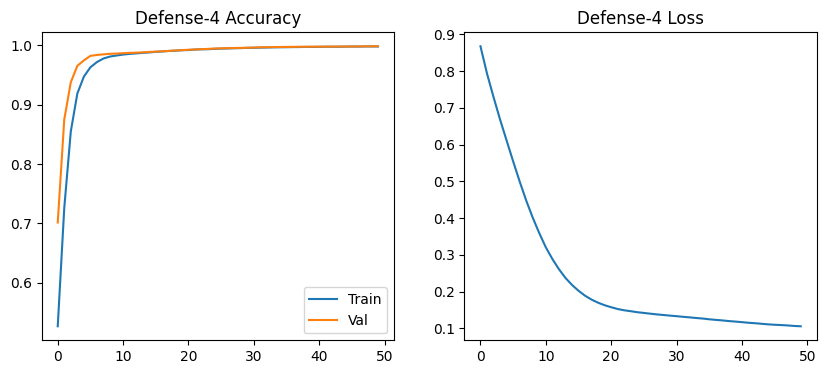

In [43]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(train_acc4,label="Train")
plt.plot(val_acc4,label="Val")
plt.title("Defense-4 Accuracy")
plt.legend()

plt.subplot(1,2,2)
plt.plot(loss_history4)
plt.title("Defense-4 Loss")

plt.show()

In [44]:
# 6.31 Defense-4 Explanation

defense_model4.eval()

ig_defense4 = IntegratedGradients(defense_model4)

sample = torch.tensor(
    X_test_phish[0:1],
    dtype=torch.float32,
    requires_grad=True
)

output = defense_model4(sample)

target = torch.argmax(output, dim=1).item()

print("Prediction:",
      torch.softmax(output, dim=1).detach().numpy())

print("Predicted Class:", target)


attr_before4 = ig_defense4.attribute(
    sample,
    target=target
)

attr_before4 = np.abs(
    attr_before4.detach().numpy()[0]
)


defense4_table = pd.DataFrame({
    "Feature": feature_phish,
    "Importance": attr_before4
})

display(
    defense4_table.sort_values(
        "Importance",
        ascending=False
    ).head(10)
)

Prediction: [[0.00709949 0.9929005 ]]
Predicted Class: 1


,Feature,Importance
21,IsHTTPS,0.104492
6,URLCharProb,0.059695
43,HasCopyrightInfo,0.057561
36,HasSocialNet,0.057547
46,NoOfJS,0.043186
15,DegitRatioInURL,0.042436
38,HasHiddenFields,0.039830
24,HasTitle,0.037424
8,NoOfSubDomain,0.030609
28,Robots,0.028965


In [45]:
# 6.32 Attack Defense-4

perturbed = sample.clone()

top_features = defense4_table.sort_values(
    "Importance",
    ascending=False
).head(3)["Feature"].values

print("Attacking Features:", top_features)


for feature in top_features:

    idx = feature_phish.index(feature)

    perturbed[0][idx] += 0.2


# Before
before_prob4 = torch.softmax(
    defense_model4(sample),
    dim=1
).detach().numpy()

before_pred4 = np.argmax(before_prob4)


# After
after_prob4 = torch.softmax(
    defense_model4(perturbed),
    dim=1
).detach().numpy()

after_pred4 = np.argmax(after_prob4)


print("Before Class:", before_pred4)
print("After Class:", after_pred4)

print("Before Prob:", before_prob4)
print("After Prob:", after_prob4)

Attacking Features: ['IsHTTPS' 'URLCharProb' 'HasCopyrightInfo']
Before Class: 1
After Class: 1
Before Prob: [[0.00709949 0.9929005 ]]
After Prob: [[0.00650783 0.9934922 ]]


In [46]:
# 6.33 Drift Defense-4

attr_after4 = ig_defense4.attribute(
    perturbed,
    target=target
)

attr_after4 = np.abs(
    attr_after4.detach().numpy()[0]
)


comparison_defense4 = pd.DataFrame({
    "Feature": feature_phish,
    "Before": attr_before4,
    "After": attr_after4
})

comparison_defense4["Drift"] = np.abs(
    comparison_defense4["Before"] -
    comparison_defense4["After"]
)

display(
    comparison_defense4.sort_values(
        "Drift",
        ascending=False
    ).head(10)
)

mean_defense4_drift = comparison_defense4["Drift"].mean()

print("Defense-4 Drift:", mean_defense4_drift)

,Feature,Before,After,Drift
21,IsHTTPS,0.104492,0.125255,0.020763
43,HasCopyrightInfo,0.057561,0.043505,0.014056
28,Robots,0.028965,0.015054,0.013911
36,HasSocialNet,0.057547,0.044585,0.012963
37,HasSubmitButton,0.015129,0.026121,0.010992
38,HasHiddenFields,0.039830,0.029713,0.010117
5,TLDLegitimateProb,0.018728,0.026859,0.008131
41,Pay,0.020965,0.013010,0.007955
46,NoOfJS,0.043186,0.036746,0.006440
6,URLCharProb,0.059695,0.065751,0.006055


Defense-4 Drift: 0.0034621286


In [47]:
comparison_all = pd.DataFrame({

    "Model":[
        "Before Defense",
        "Defense-1",
        "Defense-2",
        "Defense-3",
        "Defense-4"
    ],

    "Drift":[
        before_defense["Drift"].mean(),
        mean_defense_drift,
        mean_defense2_drift,
        mean_defense3_drift,
        mean_defense4_drift
    ]

})

comparison_all

,Model,Drift
0,Before Defense,0.038795
1,Defense-1,0.003960
2,Defense-2,0.008447
3,Defense-3,0.011453
4,Defense-4,0.003462


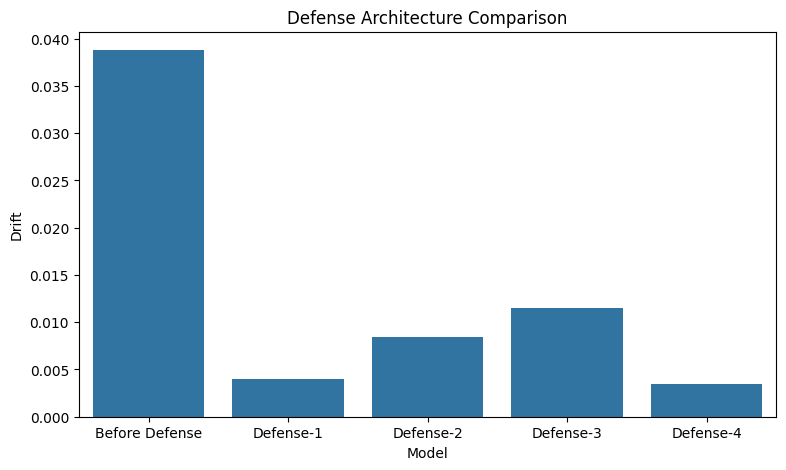

In [48]:
plt.figure(figsize=(9,5))

sns.barplot(
    data=comparison_all,
    x="Model",
    y="Drift"
)

plt.title("Defense Architecture Comparison")

plt.show()

~91% reduction in explanation drift

In [49]:
torch.save(
    defense_model4.state_dict(),
    os.path.join(
        PROJECT_ROOT,
        "models/defense_models/best_defense_model.pt"
    )
)

print("Best Defense Model Saved")

Best Defense Model Saved


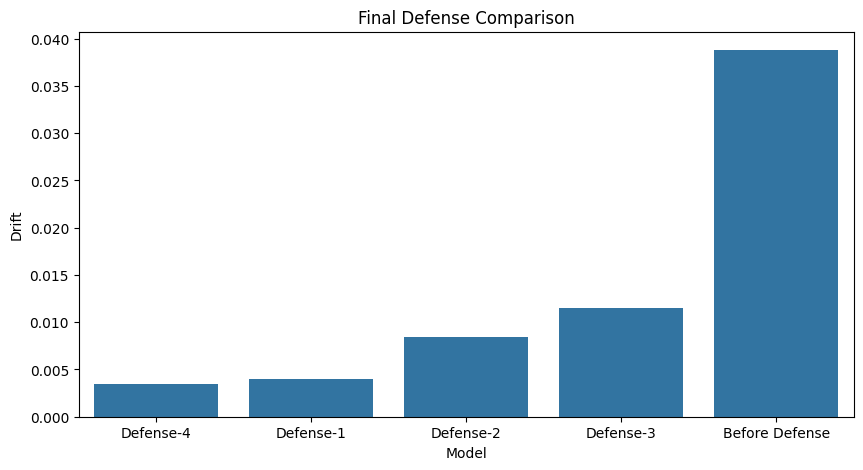

In [50]:
plt.figure(figsize=(10,5))

sns.barplot(
    data=comparison_all.sort_values("Drift"),
    x="Model",
    y="Drift"
)

plt.title("Final Defense Comparison")

plt.show()

In [51]:
# 6.36 Setup

defense_model4.eval()

ig_defense4 = IntegratedGradients(defense_model4)

sample = torch.tensor(
    X_test_phish[0:1],
    dtype=torch.float32,
    requires_grad=True
)

output = defense_model4(sample)

target = torch.argmax(output, dim=1).item()

print("Base Prediction:",
      torch.softmax(output, dim=1).detach().numpy())


attr_before4 = ig_defense4.attribute(
    sample,
    target=target
)

attr_before4 = np.abs(
    attr_before4.detach().numpy()[0]
)

base_table = pd.DataFrame({
    "Feature": feature_phish,
    "Importance": attr_before4
})

base_table.sort_values(
    "Importance",
    ascending=False
).head(10)

Base Prediction: [[0.00709949 0.9929005 ]]


,Feature,Importance
21,IsHTTPS,0.104492
6,URLCharProb,0.059695
43,HasCopyrightInfo,0.057561
36,HasSocialNet,0.057547
46,NoOfJS,0.043186
15,DegitRatioInURL,0.042436
38,HasHiddenFields,0.039830
24,HasTitle,0.037424
8,NoOfSubDomain,0.030609
28,Robots,0.028965


In [52]:
# 6.37 Attack-1
# TOP FEATURE ATTACK
perturbed1 = sample.clone()

top_features = base_table.head(3)["Feature"].values

for feature in top_features:

    idx = feature_phish.index(feature)

    perturbed1[0][idx] += 0.2


before = torch.softmax(
    defense_model4(sample), dim=1
).detach().numpy()

after = torch.softmax(
    defense_model4(perturbed1), dim=1
).detach().numpy()

print("Attack-1 Before:", before)
print("Attack-1 After:", after)


attr_after1 = ig_defense4.attribute(
    perturbed1,
    target=target
)

attr_after1 = np.abs(
    attr_after1.detach().numpy()[0]
)

drift1 = np.mean(
    np.abs(attr_before4 - attr_after1)
)

print("Attack-1 Drift:", drift1)

Attack-1 Before: [[0.00709949 0.9929005 ]]
Attack-1 After: [[0.00716174 0.9928383 ]]
Attack-1 Drift: 0.0020970625


In [53]:
# 6.38 Attack-2 LOW IMPORTANCE ATTACK

perturbed2 = sample.clone()

low_features = base_table.tail(3)["Feature"].values

for feature in low_features:

    idx = feature_phish.index(feature)

    perturbed2[0][idx] += 0.3


before = torch.softmax(
    defense_model4(sample), dim=1
).detach().numpy()

after = torch.softmax(
    defense_model4(perturbed2), dim=1
).detach().numpy()

print("Attack-2 Before:", before)
print("Attack-2 After:", after)


attr_after2 = ig_defense4.attribute(
    perturbed2,
    target=target
)

attr_after2 = np.abs(
    attr_after2.detach().numpy()[0]
)

drift2 = np.mean(
    np.abs(attr_before4 - attr_after2)
)

print("Attack-2 Drift:", drift2)

Attack-2 Before: [[0.00709949 0.9929005 ]]
Attack-2 After: [[0.00695258 0.9930474 ]]
Attack-2 Drift: 0.003536865


In [54]:
# 6.39 Attack-3 GRADIENT ATTACK

grad = torch.autograd.grad(
    defense_model4(sample).sum(),
    sample
)[0]

perturbed3 = sample + 0.15 * grad.sign()


before = torch.softmax(
    defense_model4(sample), dim=1
).detach().numpy()

after = torch.softmax(
    defense_model4(perturbed3), dim=1
).detach().numpy()

print("Attack-3 Before:", before)
print("Attack-3 After:", after)


attr_after3 = ig_defense4.attribute(
    perturbed3,
    target=target
)

attr_after3 = np.abs(
    attr_after3.detach().numpy()[0]
)

drift3 = np.mean(
    np.abs(attr_before4 - attr_after3)
)

print("Attack-3 Drift:", drift3)

Attack-3 Before: [[0.00709949 0.9929005 ]]
Attack-3 After: [[0.00863928 0.9913607 ]]
Attack-3 Drift: 0.0073480206


In [55]:
# 6.40 Attack-4 TARGETED EXPLANATION ATTACK

perturbed4 = sample.clone()

target_features = base_table.head(5)["Feature"].values

for feature in target_features:

    idx = feature_phish.index(feature)

    perturbed4[0][idx] += 0.25


before = torch.softmax(
    defense_model4(sample), dim=1
).detach().numpy()

after = torch.softmax(
    defense_model4(perturbed4), dim=1
).detach().numpy()

print("Attack-4 Before:", before)
print("Attack-4 After:", after)


attr_after4 = ig_defense4.attribute(
    perturbed4,
    target=target
)

attr_after4 = np.abs(
    attr_after4.detach().numpy()[0]
)

drift4 = np.mean(
    np.abs(attr_before4 - attr_after4)
)

print("Attack-4 Drift:", drift4)

Attack-4 Before: [[0.00709949 0.9929005 ]]
Attack-4 After: [[0.00711501 0.99288493]]
Attack-4 Drift: 0.002409445


In [56]:
defense4_results = pd.DataFrame({

    "Attack":[
        "Attack-1",
        "Attack-2",
        "Attack-3",
        "Attack-4"
    ],

    "Drift":[
        drift1,
        drift2,
        drift3,
        drift4
    ]

})

defense4_results

,Attack,Drift
0,Attack-1,0.002097
1,Attack-2,0.003537
2,Attack-3,0.007348
3,Attack-4,0.002409


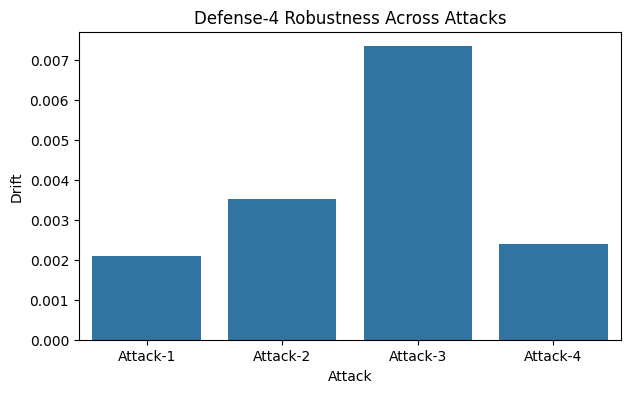

In [57]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=defense4_results,
    x="Attack",
    y="Drift"
)

plt.title("Defense-4 Robustness Across Attacks")

plt.show()

~80-95% reduction across attacks

Gradient-based attacks remain most challenging even after defense.